--------------------FASE 2 ANÁLISIS ESTADÍSTICO-------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_analisis = pd.read_csv("files/df_all_limpi.csv")
df_analisis

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,...,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,status
0,100018,2017,1,3,0,3,1521,152.0,0,0,...,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,Activo
1,100102,2017,1,10,4,14,2030,203.0,0,0,...,66889.0,Single,Nova,2887.74,Standard,2013,3,NaN,NaN,Activo
2,100140,2017,1,6,0,6,1200,120.0,0,0,...,66889.0,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN,Activo
3,100214,2017,1,0,0,0,0,0.0,0,0,...,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN,Activo
4,100272,2017,1,0,0,0,0,0.0,0,0,...,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN,Activo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403755,999902,2018,12,0,0,0,0,0.0,0,0,...,66889.0,Married,Aurora,7290.07,Standard,2014,5,NaN,NaN,Activo
403756,999911,2018,12,0,0,0,0,0.0,0,0,...,217943.0,Single,Nova,8564.77,Standard,2012,8,NaN,NaN,Activo
403757,999940,2018,12,3,0,3,1233,123.0,0,0,...,47670.0,Married,Nova,20266.50,Standard,2017,7,NaN,NaN,Activo
403758,999982,2018,12,0,0,0,0,0.0,0,0,...,66889.0,Married,Star,2631.56,Standard,2018,7,NaN,NaN,Activo


In [4]:
df_numerica = df_analisis.select_dtypes(include=["number"]).describe().T
df_numerica

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
Year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
Month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
Flights Booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
Flights with Companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
Total Flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
Distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
Points Accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
Points Redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00
Dollar Cost Points Redeemed,403760.0,2.495973,10.172033,0.00,0.00,0.00,0.00,71.00


HALLAZGO:

* El salario promedio de los clientes se situa en 76,210 mientras que la mediana en 66889. La diferencia entre ella indica que hay salarios muy altos que disparan la media. Se observa que el sueldo maximo puede llega a 407,228 lo que representa a clientes con poder adquisitivo muy alto

* El CLV 75% de los clientes tiene un valor inferior a 8,937.12, el valor máximo alcanza los 833,325.38 Esto revela la existencia de un grupo  de clientes de alto valor.

* La actividad de vuelo es mas ocasional , el cliente común (mediana) realiza 1 solo vuelo. Sin embargo, la presencia de un máximo de 32 vuelos indica un perfil de "viajeros mas frecuentes.

* La variable Distance muestra una desviación estándar alta, lo que indica que no hay un patron marcado de viajes, pues reflejan viajes desde trayectos cortos hasta rutas de larga distancia.

In [5]:
df_cat = df_analisis.select_dtypes(include=["str"]).describe().T
df_cat

,count,unique,top,freq
Country,403760,1,Canada,403760
Province,403760,11,Ontario,130258
City,403760,29,Toronto,80775
Postal Code,403760,55,V6E 3D9,21944
Gender,403760,2,Female,202757
Education,403760,5,Bachelor,252567
Marital Status,403760,3,Married,234845
Loyalty Card,403760,3,Star,183745
Enrollment Type,403760,2,Standard,380419
status,403760,2,Activo,354110


HALLAZGOS:
* Todos los datos pertenecen a Canada
* Hay 11 provincias pero la mas presente es Ontario 
* Hay 5 niveles educativos siendo el mas fuerte nivel educativo Bachelor
* La mayoria de los clientes son casados 
* Tienen 3 tipos de tarjeta pero la mas comun es la star
* El etatus de la mayoria de los clientes siguen vigentes en el programa lealtad
* hay dos tipos de innscripción siendo el standard el mas comùn


***** CRUCES DE DATOS ******

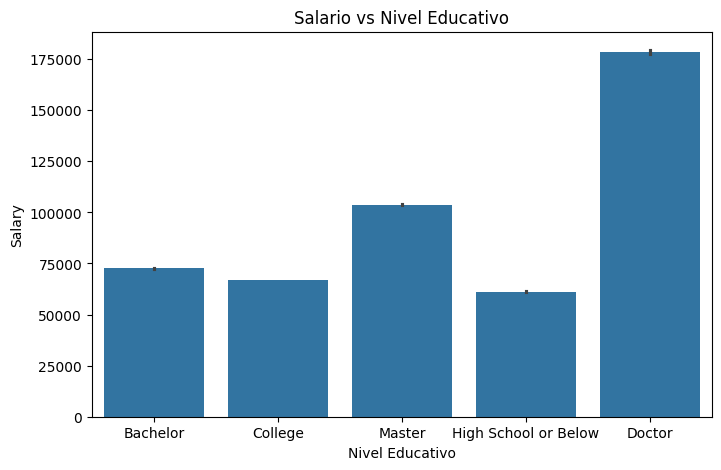

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data= df_analisis, x= "Education", y= "Salary")
plt.title("Salario vs Nivel Educativo")
plt.xlabel("Nivel Educativo")
plt.show()

Hallazgos:
* Los clientes con nivel de doctor tienen el salario mas alto con diferencia de los demas acercandose a los 180 000
* Según el nivel educativo va aumentando el suledo 
* Bachelor y college son muy similares, ya que imputamos con los salarios estimados para college 
* High school tiene el salario mas bajo 


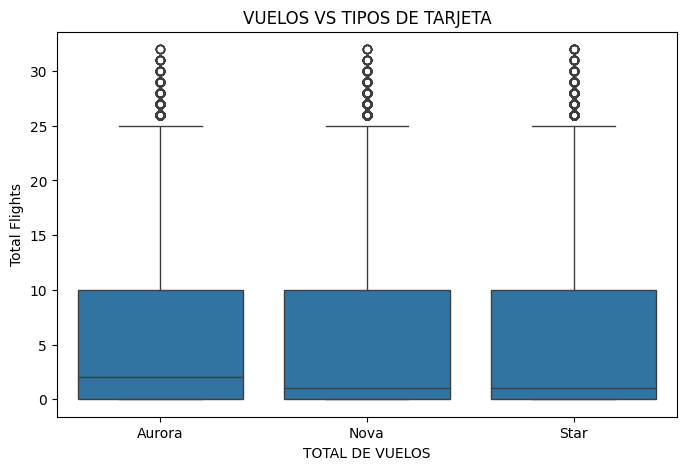

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data = df_analisis, x= "Loyalty Card", y= "Total Flights")
plt.title("VUELOS VS TIPOS DE TARJETA")
plt.xlabel("TOTAL DE VUELOS")
plt.show()

Hallazgos:
* La mediana de los vuelos sgún tarjeta se parecen mucho
* Presencia de Outliers lo que nos dice que hay clientes en todas las categorias de tarjetas con mas actividad 
* No existe relacion entre tipo de tarjeta y numero de vuelos 

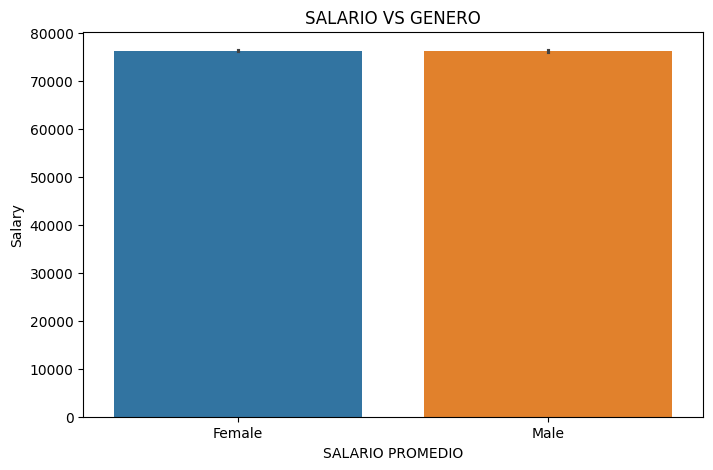

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(data= df_analisis, x= "Gender", y= "Salary", hue="Gender")
plt.title("SALARIO VS GENERO")
plt.xlabel("SALARIO PROMEDIO")
plt.show()

HALLAZGOS:
* no hay diferencia de salaior entre hombres y mujeres
* los suldos estan por encima de los 75000 no llegando a los 80 000 

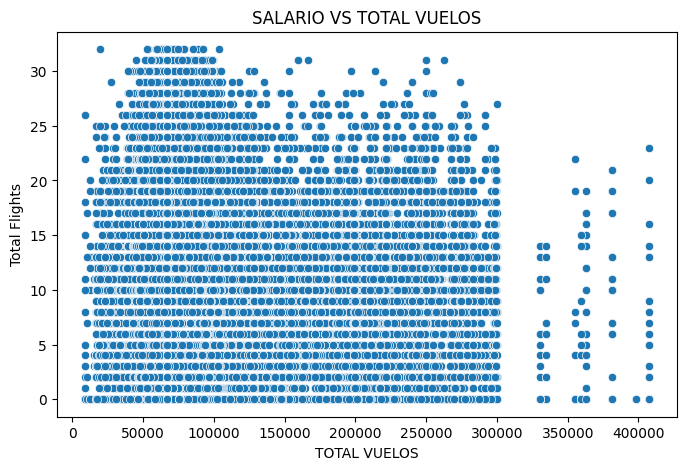

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data= df_analisis, x= "Salary", y= "Total Flights" )
plt.title("SALARIO VS TOTAL VUELOS")
plt.xlabel("TOTAL VUELOS")
plt.show()

HALLAZGOS:
* El salario no determina el numero de veces que viaja el cliente 

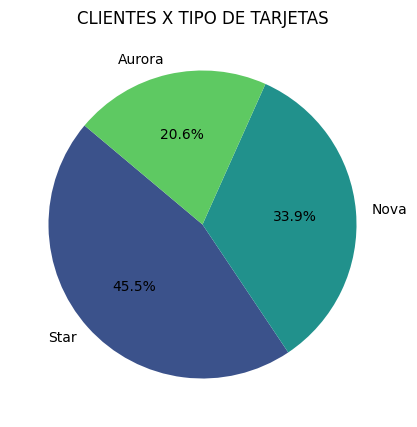

In [10]:
data_pie = df_analisis["Loyalty Card"].value_counts()

plt.figure(figsize=(8, 5))
plt.pie(data_pie, 
        labels = data_pie.index,
        autopct = "%1.1f%%", # Esto pone el porcentaje con un decimal 
        startangle =140, #gira el grafico para que se vea mejor  
        colors= sns.color_palette("viridis",len(data_pie)))
plt.title("CLIENTES X TIPO DE TARJETAS")

plt.show()

HALLAZGOS :
* 45.5% pertenecen a la tarjeta star ( es el nivel mas bajo)
* 33.9% pertenecen a la tarjeta Nova que es un nivel intermedio 
* 20.6% pertenecen a la tarjeta Aurora que indica que es un nivel mas exclusivo


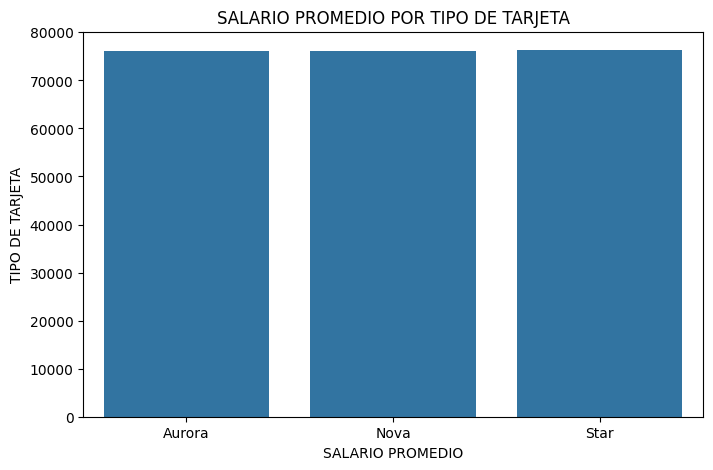

In [14]:
salario_por_tarjeta = df_analisis.groupby("Loyalty Card")["Salary"].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data= salario_por_tarjeta, x= "Loyalty Card", y= "Salary")
plt.title("SALARIO PROMEDIO POR TIPO DE TARJETA")
plt.xlabel("SALARIO PROMEDIO")
plt.ylabel("TIPO DE TARJETA")
plt.show()

HALLAZGOS:
* El nivel de tarjeta de un cliente no depende de cuanto gana 
* El salario promedio es igual en todas las tarjetas 
* El programa lealtad parece basarse ne la frecuencia de vuelos o puntos acumulados mas que salario